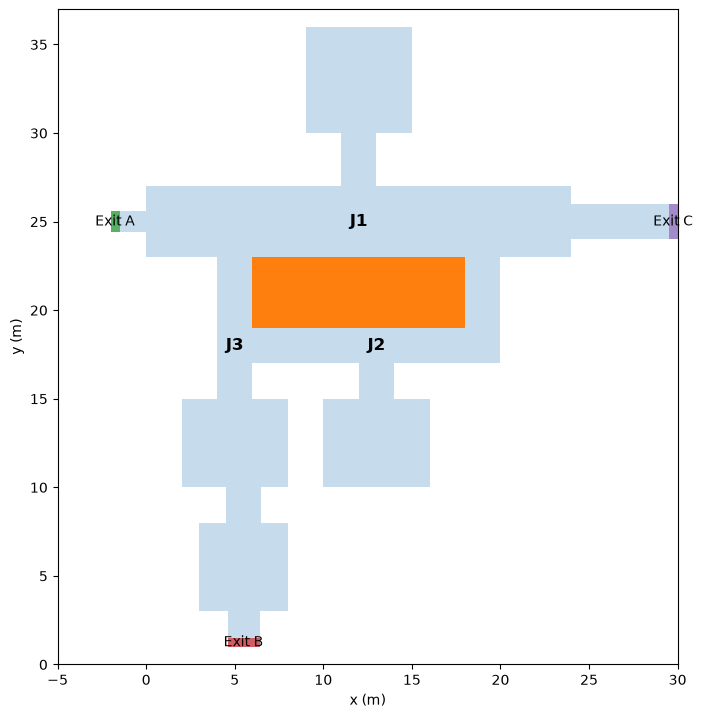

In [3]:
import matplotlib.pyplot as plt

from scenarios.building_v2 import BuildingV2Scenario


scenario = BuildingV2Scenario()

geometry = scenario.geometry


fig, ax = plt.subplots(figsize=(8, 10))


# -------------------------
# Walkable geometry
# -------------------------

x, y = geometry.exterior.xy

ax.fill(
    x,
    y,
    alpha=0.25,
)

# Plot holes / non-walkable islands
for interior in geometry.interiors:

    x, y = interior.xy

    ax.fill(
        x,
        y,
        alpha=1.0,
    )


# -------------------------
# Exit stages
# -------------------------

for name, exit_polygon in scenario.exits.items():

    x, y = exit_polygon.exterior.xy

    ax.fill(
        x,
        y,
        alpha=0.7,
    )

    center = exit_polygon.centroid

    ax.text(
        center.x,
        center.y,
        f"Exit {name}",
        ha="center",
        va="center",
    )


# -------------------------
# Junctions
# -------------------------

for name, junction in scenario.junctions.items():

    center = junction.centroid

    ax.text(
        center.x,
        center.y,
        name,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )


ax.set_aspect("equal")
ax.set_xlim(-5, 30)
ax.set_ylim(0, 37)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

plt.show()

In [1]:
import pathlib

import jupedsim as jps

from scenarios.building_v2 import BuildingV2Scenario


def record_route(room_name, exit_name, output_file, max_time=60.0):

    scenario = BuildingV2Scenario()

    output_path = pathlib.Path(output_file)

    if output_path.exists():
        output_path.unlink()

    writer = jps.SqliteTrajectoryWriter(
        output_file=output_path,
        every_nth_frame=5,
    )

    simulation = jps.Simulation(
        model=jps.CollisionFreeSpeedModel(),
        geometry=scenario.geometry,
        trajectory_writer=writer,
    )

    exit_stage_id = simulation.add_exit_stage(
        scenario.exits[exit_name]
    )

    journey_id = simulation.add_journey(
        jps.JourneyDescription([exit_stage_id])
    )

    start_position = scenario.test_positions[room_name]

    parameters = jps.CollisionFreeSpeedModelAgentParameters(
        position=start_position,
        journey_id=journey_id,
        stage_id=exit_stage_id,
    )

    simulation.add_agent(parameters)

    while (
        simulation.agent_count() > 0
        and simulation.elapsed_time() < max_time
    ):
        simulation.iterate()

    writer.close()

    print(
        f"Room {room_name} -> Exit {exit_name} "
        f"| time = {simulation.elapsed_time():.2f} s"
    )

    return output_path


if __name__ == "__main__":

    pathlib.Path("trajectories").mkdir(exist_ok=True)

    record_route(
        room_name="A",
        exit_name="B",
        output_file="trajectories/A_to_B.sqlite",
    )

Room A -> Exit B | time = 28.74 s


In [ ]:
import pathlib

import jupedsim as jps

from scenarios.building_v2 import BuildingV2Scenario
from jupedsim.internal.notebook_utils import animate, read_sqlite_file


trajectory_data, walkable_area = read_sqlite_file("trajectories/debug_C_exit.sqlite")

animation = animate(
    trajectory_data,
    walkable_area,
    every_nth_frame=50
)

animation.show()